# 06 — Modélisation : Machine Learning (Random Forest & XGBoost)

## Projet : Smart City Energy Forecasting — Tetouan

**Correspondance méthodologique :** Ce notebook couvre l'étape **12.4** de la méthodologie KDD (Data Mining / Modeling).

### Objectifs

- Reformuler le problème de séries temporelles en problème supervisé tabulaire grâce aux features (lags, rolling, météo).
- Entraîner et évaluer un modèle Random Forest (Modèle 3a).
- Entraîner et évaluer un modèle XGBoost (Modèle 3b), avec Early Stopping.
- Analyser les performances globales, par heure et par jour.
- Utiliser l'Explainable AI (SHAP) pour comprendre les décisions de XGBoost.

## 1. Imports et configuration

Nous utilisons les modules de notre architecture logicielle dans `src/`.

In [11]:
import sys
from pathlib import Path
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

# Résolution du chemin projet
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.models_ml import (
    TemporalSplitConfig,
    RandomForestConfig,
    XGBoostConfig,
    prepare_supervised_data,
    temporal_train_val_test_split,
    print_split_summary,
    train_evaluate_random_forest,
    train_evaluate_xgboost,
    evaluate_by_hour,
    evaluate_peak_load,
    feature_importance_table
)
from src.xai import (
    compute_tree_shap_values,
    plot_shap_global_importance,
    plot_shap_beeswarm,
    plot_shap_waterfall_for_peak
)

# Chemins du projet
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_METRICS_DIR = PROJECT_ROOT / "results" / "metrics"
RESULTS_PRED_DIR = PROJECT_ROOT / "results" / "predictions"
RESULTS_FIG_DIR = PROJECT_ROOT / "results" / "figures"

FEATURES_PATH = PROCESSED_DIR / "tetouan_features.csv"

for path in [RESULTS_METRICS_DIR, RESULTS_PRED_DIR, RESULTS_FIG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Racine du projet :", PROJECT_ROOT)

Racine du projet : C:\Users\jarro\OneDrive\Desktop\smart-city-energy-forecasting-tetouan


## 2. Préparation des données supervisées

Contrairement à SARIMA, XGBoost n'a pas la notion temporelle intégrée de base, mais il exploitera massivement les 98 colonnes générées au feature engineering (lags, rolling, encodage cyclique).

In [12]:
print(f"Chargement de {FEATURES_PATH}...")
df = pd.read_csv(FEATURES_PATH)
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.set_index("datetime").sort_index()

TARGET = "target"

# Préparation X, y (gère l'exclusion des features de fuite de données et garde 98 features)
X_clean, y_clean, feature_cols = prepare_supervised_data(df, target_col=TARGET)
print(f"Nombre de features sélectionnées : {len(feature_cols)}")

# Split temporel : 70% Train, 15% Val, 15% Test
split_config = TemporalSplitConfig(train_ratio=0.70, val_ratio=0.15, test_ratio=0.15)
X_train, X_val, X_test, y_train, y_val, y_test = temporal_train_val_test_split(
    X_clean, y_clean, config=split_config
)

print_split_summary(X_train, X_val, X_test)

Chargement de C:\Users\jarro\OneDrive\Desktop\smart-city-energy-forecasting-tetouan\data\processed\tetouan_features.csv...
Nombre de features sélectionnées : 105
Résumé des splits temporels
------------------------------------------------------------
Train : 2017-01-08 00:00:00 → 2017-09-14 20:00:00 | 5997 lignes
Val   : 2017-09-14 21:00:00 → 2017-11-07 09:00:00 | 1285 lignes
Test  : 2017-11-07 10:00:00 → 2017-12-30 23:00:00 | 1286 lignes


## 3. Modèle 3a — Random Forest

Random Forest sert de baseline Machine Learning très robuste qui nécessite peu de paramétrage (contrairement à XGBoost) et qui ne surapprend presque jamais si le nombre d'arbres est suffisant.

In [13]:
rf_config = RandomForestConfig(n_estimators=100, max_depth=15, n_jobs=-1)

print("Entraînement de Random Forest (ceci peut prendre une minute)...")
model_rf, metrics_rf, pred_df_rf = train_evaluate_random_forest(
    X_train, y_train,
    X_test, y_test,
    config=rf_config,
    model_name="RandomForest"
)

print("\nMétriques globales Random Forest :")
display(pd.DataFrame([metrics_rf]))

Entraînement de Random Forest (ceci peut prendre une minute)...

Métriques globales Random Forest :


,model,MAE,RMSE,MAPE,sMAPE,R2,Bias,n_obs
0,RandomForest,935.806416,1166.726593,3.246117,3.193808,0.962243,613.567183,1286


## 4. Modèle 3b — XGBoost

XGBoost est le modèle star pour les séries temporelles tabulaires riches en features. Il utilise la régularisation L1/L2 et l'early stopping sur le set de validation pour éviter le surapprentissage.

In [14]:
xgb_config = XGBoostConfig(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.85,
    tree_method="hist"  # Accélération sur grand dataset
)

print("Entraînement XGBoost avec Early Stopping sur le set de Validation...")
model_xgb, metrics_xgb, pred_df_xgb = train_evaluate_xgboost(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    config=xgb_config,
    early_stopping_rounds=50,
    model_name="XGBoost"
)

print("\nMétriques globales XGBoost :")
display(pd.DataFrame([metrics_xgb]))

Entraînement XGBoost avec Early Stopping sur le set de Validation...

Métriques globales XGBoost :


,model,MAE,RMSE,MAPE,sMAPE,R2,Bias,n_obs
0,XGBoost,606.831323,814.31401,2.087429,2.074739,0.981607,190.32704,1286


## 5. Analyse des Performances XGBoost

Comparons les performances globales de l'étape statistique avec le Machine Learning, et faisons un zoom sur les heures de pointe.

In [15]:
import os
stat_metrics_path = RESULTS_METRICS_DIR / "statistical_models_metrics.csv"
if os.path.exists(stat_metrics_path):
    stat_metrics = pd.read_csv(stat_metrics_path)
    all_metrics = pd.concat([stat_metrics, pd.DataFrame([metrics_rf, metrics_xgb])], ignore_index=True)
    print("Classement global (Top 5 par MAPE) :")
    display(all_metrics.sort_values("MAPE").head(5)[["model", "MAE", "RMSE", "MAPE", "R2"]])
else:
    print("Classement ML :")
    display(pd.DataFrame([metrics_rf, metrics_xgb]).sort_values("MAPE"))

Classement global (Top 5 par MAPE) :


,model,MAE,RMSE,MAPE,R2
7,XGBoost,606.831323,814.314010,2.087429,0.981607
0,naive_previous_week,792.878790,1098.376378,2.781035,0.966537
6,RandomForest,935.806416,1166.726593,3.246117,0.962243
1,naive_previous_day,935.394377,1434.901033,3.271021,0.942891
2,naive_previous_hour,1745.006648,2300.125141,6.015784,0.853255


In [16]:
print("Évaluation de XGBoost pendant les pics (Top 10% des charges) :")
metrics_peak = evaluate_peak_load(pred_df_xgb, quantile=0.90)
display(pd.DataFrame([metrics_peak]))

Évaluation de XGBoost pendant les pics (Top 10% des charges) :


,model,MAE,RMSE,MAPE,sMAPE,R2,Bias,n_obs,threshold,quantile
0,XGBoost_peak_q0.90,594.257532,800.312943,1.516256,1.51935,0.110303,2.188565,129,37926.816808,0.9


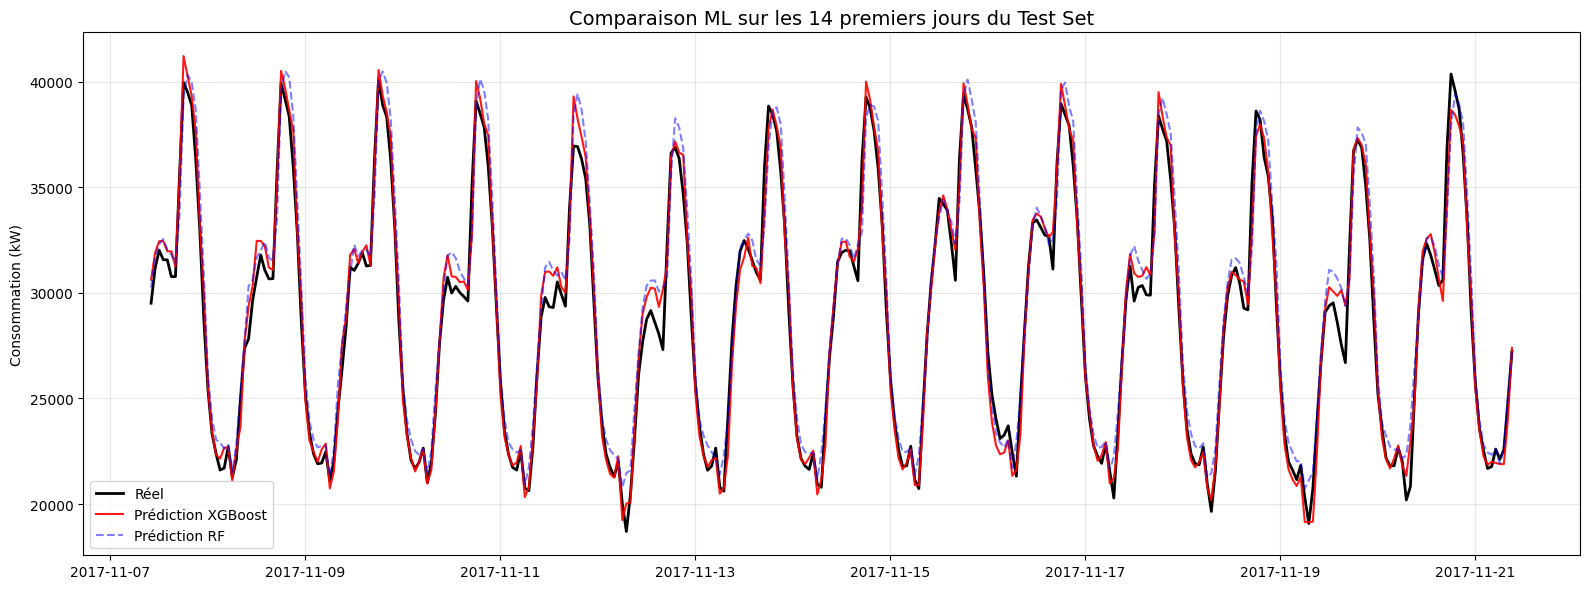

In [17]:
# Visualisation temporelle : 2 premières semaines de Test
fig, ax = plt.subplots(figsize=(16, 6))
plot_df = pred_df_xgb.iloc[:24*14].copy()

ax.plot(plot_df["datetime"], plot_df["actual"], label="Réel", color="black", linewidth=2)
ax.plot(plot_df["datetime"], plot_df["prediction"], label="Prédiction XGBoost", color="red", linewidth=1.5, alpha=0.9)
ax.plot(pred_df_rf["datetime"].iloc[:24*14], pred_df_rf["prediction"].iloc[:24*14], label="Prédiction RF", color="blue", alpha=0.5, linestyle="--")

ax.set_title("Comparaison ML sur les 14 premiers jours du Test Set", fontsize=14)
ax.set_ylabel("Consommation (kW)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_FIG_DIR / "ml_models_test_2weeks.png", dpi=150)
plt.show()

## 6. Explicabilité (SHAP)

Le Machine Learning est souvent perçu comme une 'boîte noire'. Nous utilisons la librairie SHAP (SHapley Additive exPlanations), issue de la théorie des jeux, pour calculer l'impact marginal exact de chaque variable sur les prédictions du modèle XGBoost.

Top 15 features (Importance native Gini/Gain) :


,feature,importance,rank
0,target_lag_24h,0.465930,1
1,target_lag_168h,0.143214,2
2,eval_is_high_load,0.121040,3
3,target_lag_1h,0.055200,4
4,target_lag_48h,0.048409,5
5,is_night,0.022884,6
6,hour,0.017083,7
7,is_peak_hour,0.014621,8
8,is_business_hour,0.014166,9
9,is_total_load_outlier,0.005954,10



Calcul des valeurs SHAP (sur 1000 exemples de test)...
Beeswarm plot SHAP :


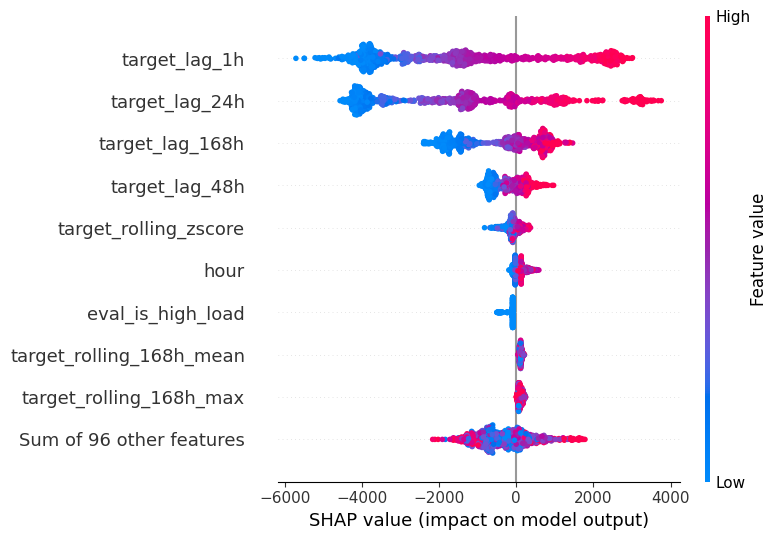

In [18]:
# 1. Table d'importance native de XGBoost
print("Top 15 features (Importance native Gini/Gain) :")
native_importance = feature_importance_table(model_xgb, X_train.columns, top_n=15)
display(native_importance)

# 2. Calcul des valeurs SHAP (sur un sous-échantillon pour la vitesse)
print("\nCalcul des valeurs SHAP (sur 1000 exemples de test)...")
X_test_sample = X_test.sample(n=1000, random_state=42).sort_index()
shap_values = compute_tree_shap_values(model_xgb, X_test_sample)

print("Beeswarm plot SHAP :")
plot_shap_beeswarm(shap_values, save_path=RESULTS_FIG_DIR / "shap_beeswarm_xgb.png")

Analyse locale (Waterfall plot) d'un des plus grands pics de consommation du test set :


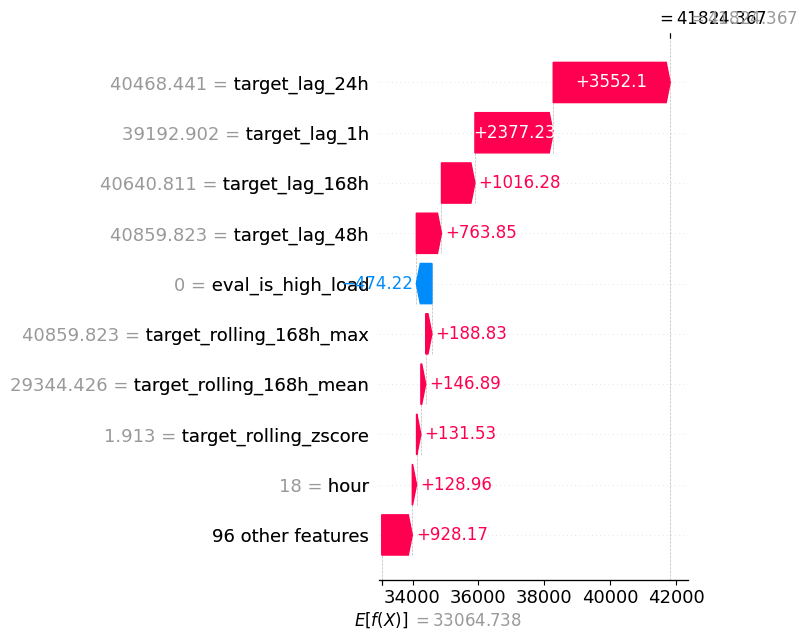

In [19]:
print("Analyse locale (Waterfall plot) d'un des plus grands pics de consommation du test set :")
plot_shap_waterfall_for_peak(
    shap_values,
    X_test_sample,
    y_reference=y_test,
    save_path=RESULTS_FIG_DIR / "shap_waterfall_peak_xgb.png"
)

In [20]:
# Sauvegardes finales
pred_df_xgb.to_csv(RESULTS_PRED_DIR / "xgboost_predictions.csv", index=False)
pred_df_rf.to_csv(RESULTS_PRED_DIR / "random_forest_predictions.csv", index=False)
pd.DataFrame([metrics_xgb, metrics_rf]).to_csv(RESULTS_METRICS_DIR / "ml_models_metrics.csv", index=False)

print("✅ Modélisation Machine Learning terminée et sauvegardée.")

✅ Modélisation Machine Learning terminée et sauvegardée.
